## NB02 — QR Detection & Metric Calibration

Reads preprocessed images from `outputs/01_preprocessed/`, detects the 3 QR codes
visually (no decoder needed), computes an affine transform that maps the image to an
800×800 px metric space where **1 px = 1 mm**, and saves:

- Rectified images → `outputs/02_rectified/`
- `calibration.json` → used by NB03, NB04, NB05, NB06

**Key design decisions:**
- QR exterior corners define the 800×800 mm reference square
- Affine transform (3 points) corrects perspective and scale
- QR bboxes are expanded to cover the full physical QR (including white margin)
  so that NB06 evaluation against Roboflow GT is fair

In [12]:
!pip install opencv-python numpy matplotlib

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [14]:
# ── Paths ──────────────────────────────────────────────────────────────────
PREPROCESSED_DIR = Path("outputs/01_preprocessed")
OUTPUT_DIR       = Path("outputs/02_rectified")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEBUG_DIR         = OUTPUT_DIR / "debug"
ALL_CANDS_DIR     = DEBUG_DIR / "all_candidates"
FINAL_QRS_DIR     = DEBUG_DIR / "final_qrs"

for d in [ALL_CANDS_DIR, FINAL_QRS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Physical reference ─────────────────────────────────────────────────────
# The 3 QR exterior corners define an 800 mm × 800 mm square on the table.
QR_LEG_MM      = 800.0
RECTIFIED_SIZE = int(QR_LEG_MM)   # output image: 800×800 px → 1 px = 1 mm

# ── QR candidate detection ─────────────────────────────────────────────────
# Size limits as fraction of image diagonal
MIN_SIZE_RATIO = 0.006
MAX_SIZE_RATIO = 0.080
# White ring around candidate (QR always has white quiet zone)
MIN_WHITE_RING = 0.45
# Internal edge density (QR has many black/white transitions)
MIN_EDGE_DENSITY = 0.08
# How much to expand the raw detected bbox to cover the full physical QR
# (includes quiet zone). A factor of 1.6 adds ~30% on each side.
QR_BBOX_EXPAND_FACTOR = 1.6

# ── Corner assignment ──────────────────────────────────────────────────────
# QRs must be within this fraction of the image diagonal from a corner
MAX_CORNER_DIST_RATIO = 0.30
EXPECTED_QRS = 3

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}
DATASET_PREFIX   = "Multimedia_"

print(f"Preprocessed dir : {PREPROCESSED_DIR.resolve()}")
print(f"Output dir       : {OUTPUT_DIR.resolve()}")
print(f"Rectified size   : {RECTIFIED_SIZE}×{RECTIFIED_SIZE} px  (1 px = 1 mm)")
print(f"QR bbox expand   : ×{QR_BBOX_EXPAND_FACTOR}")

Preprocessed dir : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\01_preprocessed
Output dir       : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified
Rectified size   : 800×800 px  (1 px = 1 mm)
QR bbox expand   : ×1.6


In [15]:
def expand_bbox(bbox, factor, img_shape):
    """
    Expand a bbox by 'factor' around its centre, clamped to image bounds.
    Used to make the saved QR bbox cover the full physical QR including
    the white quiet zone, so NB06 evaluation IoU against Roboflow GT is fair.
    """
    x, y, w, h = bbox
    H, W = img_shape[:2]
    cx, cy = x + w / 2.0, y + h / 2.0
    nw, nh = w * factor, h * factor
    nx = max(0, int(cx - nw / 2))
    ny = max(0, int(cy - nh / 2))
    nx2 = min(W, int(cx + nw / 2))
    ny2 = min(H, int(cy + nh / 2))
    return (nx, ny, nx2 - nx, ny2 - ny)


def _merge_close(candidates, dist_factor=1.5):
    """Keep only the best candidate within each local neighbourhood."""
    merged = []
    for c in sorted(candidates, key=lambda z: z.get("score", 0), reverse=True):
        cx, cy = c["center"]
        if any(np.hypot(cx - m["center"][0], cy - m["center"][1])
               < dist_factor * max(c["size"], m["size"])
               for m in merged):
            continue
        merged.append(c)
    return merged


def detect_qr_candidates(img_gray: np.ndarray) -> list:
    """
    Detect QR-like regions visually (no decoder).

    Strategy: try 3 binarisation methods, find square-ish contours
    with high internal edge density and a bright ring around them.
    Returns a de-duplicated, score-sorted list.

    Each candidate bbox is the RAW detected bbox (tight around the
    dark pattern). Use expand_bbox() for the full physical QR size.
    """
    H, W = img_gray.shape
    diag = np.hypot(H, W)
    min_sz = int(diag * MIN_SIZE_RATIO)
    max_sz = int(diag * MAX_SIZE_RATIO)

    binaries = [
        cv2.adaptiveThreshold(img_gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 5),
        cv2.adaptiveThreshold(img_gray, 255,
            cv2.ADAPTIVE_THRESH_MEAN_C,    cv2.THRESH_BINARY_INV, 21, 7),
        cv2.threshold(img_gray, 0, 255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1],
    ]

    candidates = []
    for binary in binaries:
        cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in cnts:
            x, y, w, h = cv2.boundingRect(cnt)
            size = max(w, h)
            if not (min_sz <= size <= max_sz):
                continue
            aspect = w / (h + 1e-6)
            if not (0.55 <= aspect <= 1.8):
                continue
            if cv2.contourArea(cnt) / (w * h + 1e-6) < 0.05:
                continue

            # White quiet-zone ring check
            pad = int(size * 1.4)
            x1, y1 = max(0, x - pad), max(0, y - pad)
            x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
            ring = img_gray[y1:y2, x1:x2].copy()
            ix1 = max(0, x - x1); iy1 = max(0, y - y1)
            ix2 = min(ring.shape[1], x + w - x1)
            iy2 = min(ring.shape[0], y + h - y1)
            ring[iy1:iy2, ix1:ix2] = 0
            vals = ring[ring > 0]
            white_ring = float(np.mean(vals > 135)) if vals.size else 0.0
            if white_ring < MIN_WHITE_RING:
                continue

            # Internal edge density check
            roi = img_gray[y:y + h, x:x + w]
            edge_density = float(np.mean(cv2.Canny(roi, 40, 120) > 0))
            if edge_density < MIN_EDGE_DENSITY:
                continue

            score = white_ring + edge_density - abs(aspect - 1.0) * 0.5
            candidates.append({
                "center":       (float(x + w / 2), float(y + h / 2)),
                "size":         float(size),
                "bbox_raw":     (int(x), int(y), int(w), int(h)),   # tight bbox
                "score":        score,
                "white_ring":   white_ring,
                "edge_density": edge_density,
                "aspect":       float(aspect),
            })

    return _merge_close(sorted(candidates, key=lambda c: c["score"], reverse=True))

In [16]:
# Destination points in metric space (mm), one per QR corner label
METRIC_POINTS = {
    "TL": np.array([0.0,       0.0      ], dtype=np.float32),
    "TR": np.array([QR_LEG_MM, 0.0      ], dtype=np.float32),
    "BL": np.array([0.0,       QR_LEG_MM], dtype=np.float32),
    "BR": np.array([QR_LEG_MM, QR_LEG_MM], dtype=np.float32),
}


def assign_to_corners(img_shape, candidates):
    """Assign each candidate to the nearest image corner."""
    img_h, img_w = img_shape[:2]
    diag = np.hypot(img_h, img_w)
    max_dist = MAX_CORNER_DIST_RATIO * diag

    corner_pts = {
        "TL": np.array([0.0,           0.0          ]),
        "TR": np.array([img_w - 1.0,   0.0          ]),
        "BL": np.array([0.0,           img_h - 1.0  ]),
        "BR": np.array([img_w - 1.0,   img_h - 1.0  ]),
    }

    out = []
    for c in candidates:
        c = c.copy()
        cx, cy = c["center"]
        dists = {lbl: float(np.hypot(cx - pt[0], cy - pt[1]))
                 for lbl, pt in corner_pts.items()}
        nearest = min(dists, key=dists.get)
        nd = dists[nearest]
        corner_score = 1.0 - min(nd / max_dist, 1.0)
        c["corner_label"]    = nearest if nd <= max_dist else "OUT"
        c["corner_dist_px"]  = nd
        c["corner_score"]    = corner_score
        c["final_score"]     = c["score"] * (1.0 + 0.5 * corner_score)
        out.append(c)

    return sorted(out, key=lambda c: c["final_score"], reverse=True)


def select_qrs(assigned, expected=EXPECTED_QRS):
    """Keep the best candidate per corner, up to expected count."""
    best = {}
    for c in assigned:
        lbl = c["corner_label"]
        if lbl == "OUT":
            continue
        if lbl not in best or c["final_score"] > best[lbl]["final_score"]:
            best[lbl] = c

    items = sorted(best.items(), key=lambda t: t[1]["final_score"], reverse=True)
    if len(items) > expected:
        items = items[:expected]

    order = ["TL", "TR", "BL", "BR"]
    return {lbl: best[lbl] for lbl in order if lbl in dict(items)}


def exterior_corner(label, bbox_raw, img_shape):
    """
    Return the exterior reference point of a QR for the affine transform.
    This is the image-corner-facing vertex of the RAW bbox.
    (We use the raw bbox here, not the expanded one, to keep the
    geometric transform accurate.)
    """
    x, y, w, h = bbox_raw
    if label == "TL": return np.array([x,     y    ], dtype=np.float32)
    if label == "TR": return np.array([x + w, y    ], dtype=np.float32)
    if label == "BL": return np.array([x,     y + h], dtype=np.float32)
    if label == "BR": return np.array([x + w, y + h], dtype=np.float32)
    raise ValueError(f"Unknown label: {label}")


def compute_affine(selected_qrs, img_shape):
    """
    Compute affine transform: image px → metric mm (800×800).
    Returns A (2×3), H (3×3), src_pts, dst_pts.
    """
    labels = list(selected_qrs.keys())
    if len(labels) != 3:
        raise ValueError(f"Need exactly 3 QRs, got {len(labels)}")

    src_pts = np.array([exterior_corner(lbl, selected_qrs[lbl]["bbox_raw"], img_shape)
                        for lbl in labels], dtype=np.float32)
    dst_pts = np.array([METRIC_POINTS[lbl] for lbl in labels], dtype=np.float32)

    A = cv2.getAffineTransform(src_pts, dst_pts).astype(np.float32)
    H = np.vstack([A, [0, 0, 1]]).astype(np.float32)
    return A, H, src_pts, dst_pts


def estimate_px_per_mm(src_pts, dst_pts):
    """Diagnostic: original image scale before rectification."""
    ratios = []
    for i in range(len(src_pts)):
        for j in range(i + 1, len(src_pts)):
            pd = np.linalg.norm(src_pts[i] - src_pts[j])
            md = np.linalg.norm(dst_pts[i] - dst_pts[j])
            if md > 1e-6:
                ratios.append(pd / md)
    return float(np.mean(ratios)) if ratios else float("nan")


def rectify(img, A):
    """Warp image to 800×800 metric space."""
    return cv2.warpAffine(img, A, (RECTIFIED_SIZE, RECTIFIED_SIZE),
                          flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0)

In [17]:
def draw_debug_all(image_name, img_gray, assigned_cands):
    """Save all candidates colour-coded by corner assignment."""
    dbg = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    for c in assigned_cands:
        x, y, w, h = c["bbox_raw"]
        lbl = c.get("corner_label", "?")
        color = (255, 0, 0) if lbl != "OUT" else (80, 80, 80)
        cv2.rectangle(dbg, (x, y), (x + w, y + h), color, 2)
        cv2.putText(dbg, f"{lbl} {c['final_score']:.2f}",
                    (x, max(14, y - 4)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.4, color, 1, cv2.LINE_AA)
    cv2.imwrite(str(ALL_CANDS_DIR / f"{Path(image_name).stem}_all.png"), dbg)


def draw_debug_final(image_name, img_gray, selected_qrs, src_pts):
    """Save image with final QR selections: raw bbox + expanded bbox + reference point."""
    dbg = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    H_img = img_gray.shape[0]
    W_img = img_gray.shape[1]

    colors = {"TL": (0,255,0), "TR": (0,255,255), "BL": (255,0,255), "BR": (0,165,255)}

    for lbl, cand in selected_qrs.items():
        color = colors.get(lbl, (255,255,255))
        x, y, w, h = cand["bbox_raw"]

        # Raw bbox (thin)
        cv2.rectangle(dbg, (x, y), (x + w, y + h), color, 1)

        # Expanded bbox (thick) — what gets saved to calibration.json as qr_bbox_full
        ex, ey, ew, eh = cand["bbox_full"]
        cv2.rectangle(dbg, (ex, ey), (ex + ew, ey + eh), color, 3)

        cv2.putText(dbg, f"{lbl} | {cand['final_score']:.2f}",
                    (ex, max(18, ey - 6)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.55, color, 2, cv2.LINE_AA)

    # Reference points used for affine transform (red cross)
    for cx, cy in src_pts:
        cv2.drawMarker(dbg, (int(cx), int(cy)), (0,0,255),
                       cv2.MARKER_CROSS, 18, 2)

    cv2.imwrite(str(FINAL_QRS_DIR / f"{Path(image_name).stem}_final_qrs.png"), dbg)

In [18]:
def process_image(image_name: str) -> dict | None:
    """
    Full pipeline for one image:
      1. Detect QR candidates
      2. Assign to image corners
      3. Select best 3
      4. Compute affine transform (uses RAW bbox exterior corners for accuracy)
      5. Expand bboxes for evaluation (covers full physical QR)
      6. Rectify and save image
      7. Return calibration record

    calibration.json fields consumed downstream:
      NB03/04/05 : px_per_mm (=1.0 in rectified space)
      NB06 det.  : A_image_to_metric (transform GT bboxes to rectified space)
      NB06 QR    : qr_labels_full    (expanded bboxes, orig px coords)
      NB06 diag  : corners_px, selected_labels, qr_scores, px_per_mm_original
    """
    pre_path = PREPROCESSED_DIR / image_name
    img_gray = cv2.imread(str(pre_path), cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"  [SKIP] {image_name}: cannot load")
        return None

    raw_cands  = detect_qr_candidates(img_gray)
    assigned   = assign_to_corners(img_gray.shape, raw_cands)
    draw_debug_all(image_name, img_gray, assigned)

    if len(assigned) < 3:
        print(f"  [WARN] {image_name}: only {len(assigned)} candidates found")
        return None

    selected = select_qrs(assigned)

    if len(selected) != 3:
        print(f"  [WARN] {image_name}: got {len(selected)} QRs after selection, need 3")
        return None

    # Expand bboxes AFTER selection (for evaluation only, not for transform)
    for lbl, cand in selected.items():
        cand["bbox_full"] = expand_bbox(cand["bbox_raw"], QR_BBOX_EXPAND_FACTOR, img_gray.shape)

    try:
        A, H, src_pts, dst_pts = compute_affine(selected, img_gray.shape)
    except ValueError as e:
        print(f"  [WARN] {image_name}: {e}")
        return None

    px_per_mm_orig = estimate_px_per_mm(src_pts, dst_pts)

    rect = rectify(img_gray, A)
    cv2.imwrite(str(OUTPUT_DIR / image_name), rect)

    draw_debug_final(image_name, img_gray, selected, src_pts)

    print(f"  [OK]  {image_name:30s}  labels={list(selected.keys())}  "
          f"orig_px/mm={px_per_mm_orig:.3f}")

    return {
        "image_name"              : image_name,
        "selected_labels"         : list(selected.keys()),
        # ── Transform (used by NB06 to map GT bboxes to rectified space) ──
        "A_image_to_metric"       : A.tolist(),
        "H_image_to_metric"       : H.tolist(),
        # ── Scale (used by NB04/05) ────────────────────────────────────────
        "px_per_mm"               : 1.0,              # rectified: 1 px = 1 mm
        "px_per_mm_original_estimate": px_per_mm_orig,
        "rectified_size_px"       : RECTIFIED_SIZE,
        # ── QR bboxes for NB06 evaluation ─────────────────────────────────
        # bbox_full: expanded bbox in ORIGINAL image px coords
        # This is what gets compared against Roboflow GT annotations
        "qr_labels"               : {lbl: list(c["bbox_raw"])
                                       for lbl, c in selected.items()},
        "qr_labels_full"          : {lbl: list(c["bbox_full"])
                                       for lbl, c in selected.items()},
        # ── Geometry (diagnostic) ─────────────────────────────────────────
        "corners_px"              : src_pts.tolist(),
        "metric_points_mm"        : dst_pts.tolist(),
        # ── Scores (diagnostic) ───────────────────────────────────────────
        "qr_scores"               : {
            lbl: {
                "raw_score"   : float(c.get("score", 0)),
                "final_score" : float(c.get("final_score", 0)),
                "corner_score": float(c.get("corner_score", 0)),
                "white_ring"  : float(c.get("white_ring", 0)),
                "edge_density": float(c.get("edge_density", 0)),
            }
            for lbl, c in selected.items()
        },
    }

In [19]:
image_names = sorted([
    p.name for p in PREPROCESSED_DIR.iterdir()
    if p.suffix.lower() in VALID_EXTENSIONS
    and p.name.startswith(DATASET_PREFIX)
])

print(f"Found {len(image_names)} preprocessed images\n")

calibration_data = {}

for name in image_names:
    result = process_image(name)
    if result is not None:
        calibration_data[name] = result

print(f"\nProcessed {len(calibration_data)} / {len(image_names)} successfully")

calib_path = OUTPUT_DIR / "calibration.json"
with open(calib_path, "w", encoding="utf-8") as f:
    json.dump(calibration_data, f, indent=2)

print(f"Calibration saved → {calib_path}")

Found 22 preprocessed images

  [OK]  Multimedia_31.jpg               labels=['TL', 'TR', 'BR']  orig_px/mm=1.579
  [OK]  Multimedia_32.jpg               labels=['TL', 'TR', 'BR']  orig_px/mm=1.605
  [OK]  Multimedia_33.jpg               labels=['TL', 'TR', 'BR']  orig_px/mm=1.543
  [OK]  Multimedia_34.jpg               labels=['TL', 'TR', 'BR']  orig_px/mm=1.576
  [OK]  Multimedia_35.jpg               labels=['TL', 'TR', 'BL']  orig_px/mm=1.408
  [OK]  Multimedia_36.jpg               labels=['TL', 'TR', 'BL']  orig_px/mm=1.408
  [OK]  Multimedia_37.jpg               labels=['TL', 'TR', 'BL']  orig_px/mm=1.480
  [WARN] Multimedia_38.jpg: got 2 QRs after selection, need 3
  [OK]  Multimedia_39.jpg               labels=['TL', 'TR', 'BR']  orig_px/mm=1.412
  [OK]  Multimedia_40.jpg               labels=['TL', 'TR', 'BR']  orig_px/mm=1.352
  [OK]  Multimedia_41.jpg               labels=['TL', 'TR', 'BR']  orig_px/mm=1.372
  [OK]  Multimedia_42.jpg               labels=['TL', 'TR', 'BR']  o

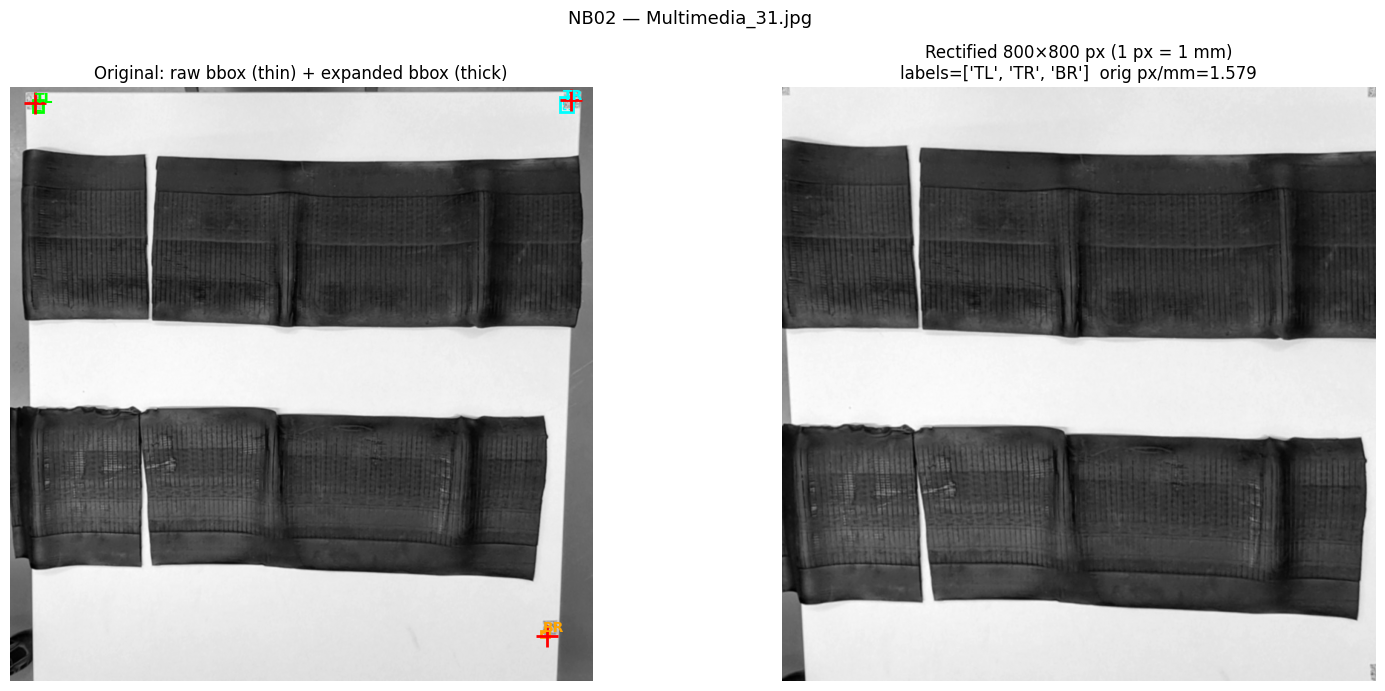

In [20]:
def visualize(image_name):
    if image_name not in calibration_data:
        print("Not in calibration_data")
        return

    calib    = calibration_data[image_name]
    original = cv2.imread(str(PREPROCESSED_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    rectified= cv2.imread(str(OUTPUT_DIR / image_name),       cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"NB02 — {image_name}", fontsize=13)

    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Original: raw bbox (thin) + expanded bbox (thick)")

    colors = {"TL": "lime", "TR": "cyan", "BL": "magenta", "BR": "orange"}

    # Draw both bboxes
    for lbl, bbox_raw in calib["qr_labels"].items():
        x, y, w, h = bbox_raw
        color = colors.get(lbl, "yellow")
        import matplotlib.patches as patches
        axes[0].add_patch(patches.Rectangle((x, y), w, h,
            linewidth=1, edgecolor=color, facecolor="none", linestyle="--"))
        axes[0].annotate(lbl, (x, y), color=color, fontsize=10, fontweight="bold")

    for lbl, bbox_full in calib["qr_labels_full"].items():
        x, y, w, h = bbox_full
        color = colors.get(lbl, "yellow")
        axes[0].add_patch(patches.Rectangle((x, y), w, h,
            linewidth=2, edgecolor=color, facecolor="none"))

    for cx, cy in calib["corners_px"]:
        axes[0].plot(cx, cy, "r+", markersize=16, markeredgewidth=2)

    axes[0].axis("off")

    axes[1].imshow(rectified, cmap="gray")
    axes[1].set_title(f"Rectified 800×800 px (1 px = 1 mm)\n"
                      f"labels={calib['selected_labels']}  "
                      f"orig px/mm={calib['px_per_mm_original_estimate']:.3f}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(DEBUG_DIR / f"check_{Path(image_name).stem}.png", dpi=120)
    plt.show()


if calibration_data:
    visualize(next(iter(calibration_data)))
else:
    print("No images processed.")

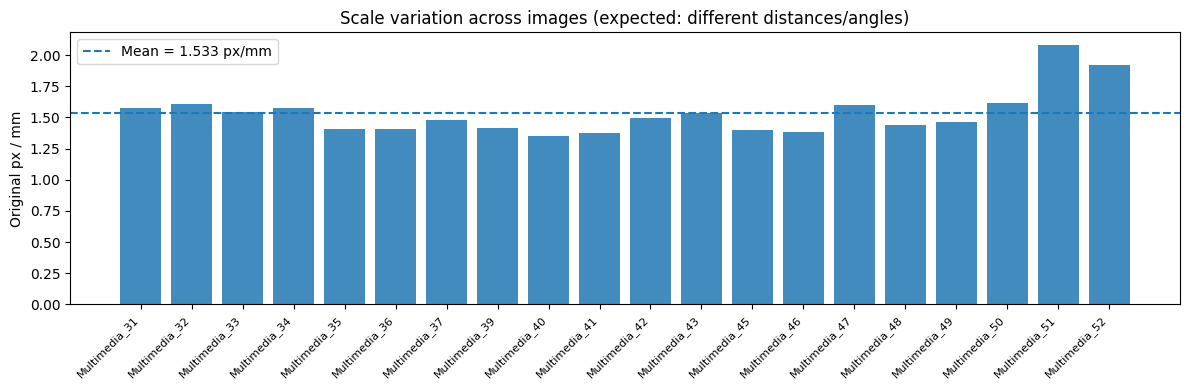

Mean  : 1.533
Std   : 0.177
Min   : 1.352  (Multimedia_40.jpg)
Max   : 2.078  (Multimedia_51.jpg)


In [21]:
if calibration_data:
    names  = list(calibration_data.keys())
    scales = [calibration_data[n]["px_per_mm_original_estimate"] for n in names]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(names)), scales, alpha=0.85)
    ax.axhline(np.mean(scales), linestyle="--",
               label=f"Mean = {np.mean(scales):.3f} px/mm")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([Path(n).stem for n in names], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Original px / mm")
    ax.set_title("Scale variation across images (expected: different distances/angles)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(DEBUG_DIR / "scale_distribution.png", dpi=150)
    plt.show()

    print(f"Mean  : {np.mean(scales):.3f}")
    print(f"Std   : {np.std(scales):.3f}")
    print(f"Min   : {np.min(scales):.3f}  ({names[int(np.argmin(scales))]})")
    print(f"Max   : {np.max(scales):.3f}  ({names[int(np.argmax(scales))]})")